In [178]:
import geopandas as gpd
from shapely.ops import linemerge
import matplotlib.pyplot as plt
from shapely.ops import unary_union, linemerge, nearest_points
from shapely.geometry import LineString, MultiLineString, GeometryCollection, Point, MultiPolygon, Polygon, MultiPoint
import numpy as np
from scipy.interpolate import splprep, splev

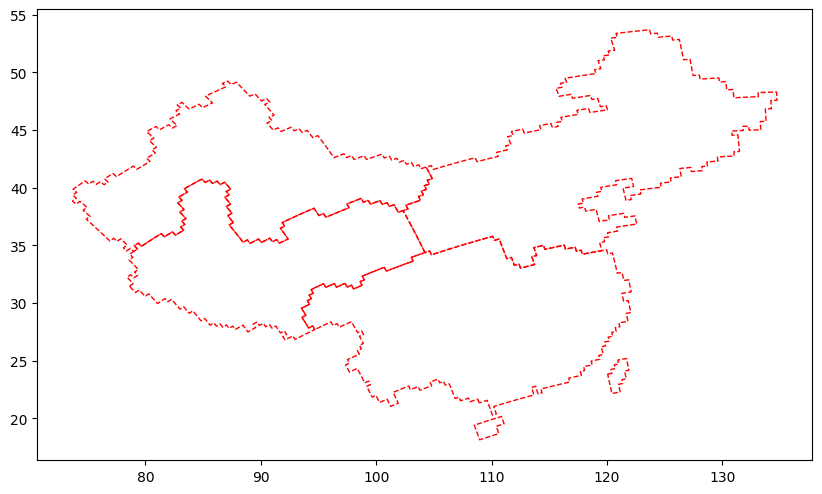

In [179]:
#融合cluster为region
def merge_clusters_to_regions(input_file, dissolve=True):
    # ---- 1. 读取 GeoJSON ----
    gdf = gpd.read_file(input_file)
    
    # ---- 2. 定义 cluster 到 region 的映射 ----
    cluster_to_region = {
        1: "region1", 2: "region1", 3: "region1", 4: "region1",
        5: "region2", 6: "region2", 7: "region2", 8: "region2",
        9: "region3", 10: "region3",
        11: "region4", 12: "region4", 13: "region4"
    }
    
    # ---- 3. 创建新的 region 列 ----
    gdf["region"] = gdf["cluster"].map(cluster_to_region)
    
    # ---- 4. 合并同一 region 的几何（可选） ----
    if dissolve:
        gdf = gdf.dissolve(by="region", as_index=False)

    # 绘图检查
    fig, ax = plt.subplots(figsize=(10, 10))
    for i in range(4):
        tmp=gdf[gdf['region']==f'region{i+1}']
        tmp.plot(ax=ax, facecolor='none', edgecolor='red', linestyle='--', label='Original Clusters')
    ax.set_aspect('equal')
    plt.show()

    # ---- 5. 保存为新的 GeoJSON ----
    return gdf

region=merge_clusters_to_regions(input_file='output/scenario=all/cell=40km/threshold=5/cluster_number/all_40km_5_zone_boundary_20260115.geojson')

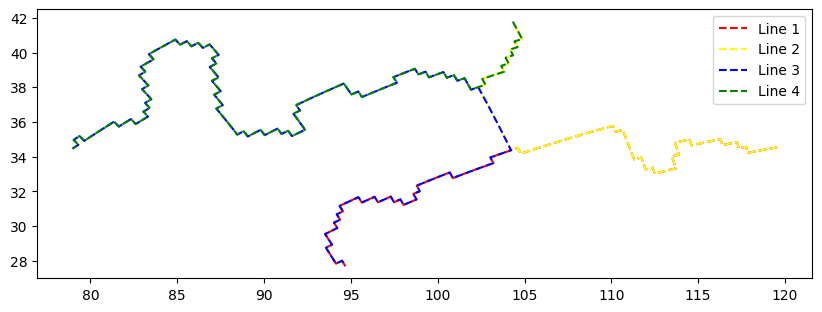

In [180]:
# 提取region的内部边界（修正版）
def extract_internal_boundaries_safe(clusters_gdf):
    # --- 合并所有簇 polygon
    all_union = unary_union(clusters_gdf.geometry)

    internal_lines = []
    line_ids = []
    line_id_counter = 1  # 编号起始值

    for poly in clusters_gdf.geometry:
        if poly is None or poly.is_empty:
            continue

        # --- 其他簇的几何 (排除当前簇)
        others = all_union.difference(poly)
        if others is None or others.is_empty:
            continue

        # --- 当前簇边界与其他簇交集部分 → 内部共享边界
        internal = poly.boundary.intersection(others)
        if internal.is_empty:
            continue

        # --- 提取所有 LineString
        def extract_lines(geom):
            lines = []
            if geom.geom_type == "LineString":
                lines.append(geom)
            elif geom.geom_type == "MultiLineString":
                lines.extend(list(geom.geoms))
            elif geom.geom_type == "GeometryCollection":
                for g in geom.geoms:
                    lines.extend(extract_lines(g))
            return lines

        lines = extract_lines(internal)
        if not lines:
            continue

        # --- 合并相连线段
        merged = linemerge(lines)

        # --- 统一处理 linemerge 输出
        if merged.geom_type == "LineString":
            internal_lines.append(merged)
            line_ids.append(line_id_counter)
            line_id_counter += 1

        elif merged.geom_type == "MultiLineString":
            for g in merged.geoms:
                internal_lines.append(g)
                line_ids.append(line_id_counter)
                line_id_counter += 1

    # --- 构建 GeoDataFrame
    return gpd.GeoDataFrame(
        {
            "line_id": line_ids,
            "geometry": internal_lines
        },
        crs=clusters_gdf.crs
    )

# 使用修正版函数
line = extract_internal_boundaries_safe(region)

# 绘图检查
colors = ['red', 'yellow', 'blue', 'green']
fig, ax = plt.subplots(figsize=(10, 10))
for i in range(4):
    tmp = line[line['line_id'] == (i + 1)].reset_index(drop=True)
    tmp.plot(ax=ax, facecolor='none', edgecolor=colors[i], linestyle='--', label=f'Line {i+1}')
ax.set_aspect('equal')
plt.legend()
plt.show()

最终线段数量： 5


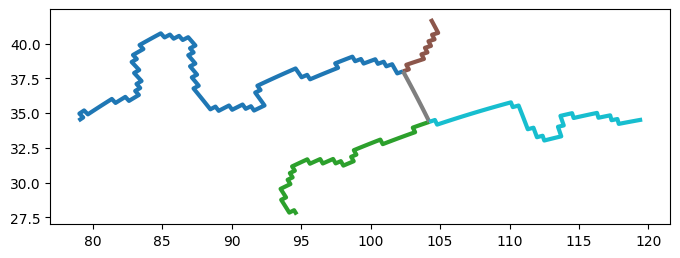

In [181]:
#把4条边界线转化为5条不重合的曲线
def merge_overlapping_lines_to_segments(line_gdf):
    # 1. 先做 union（去掉重复拓扑）
    unioned = unary_union(line_gdf.geometry)

    # 2. 再做 linemerge（关键！合并所有共线重叠线）
    merged = linemerge(unioned)

    # 3. 提取最终线段
    def extract_lines(geom):
        lines = []
        if geom.is_empty:
            return lines
        if geom.geom_type == "LineString":
            lines.append(geom)
        elif geom.geom_type == "MultiLineString":
            lines.extend(list(geom.geoms))
        elif geom.geom_type == "GeometryCollection":
            for g in geom.geoms:
                lines.extend(extract_lines(g))
        return lines

    final_lines = extract_lines(merged)

    return gpd.GeoDataFrame(
        {
            "segment_id": range(1, len(final_lines) + 1),
            "geometry": final_lines
        },
        crs=line_gdf.crs
    )

# ================= 使用 =================

segments = merge_overlapping_lines_to_segments(line)

print("最终线段数量：", len(segments))

fig, ax = plt.subplots(figsize=(8, 8))
segments.plot(
    ax=ax,
    column="segment_id",
    cmap="tab10",
    linewidth=3,
    legend=False
)
ax.set_aspect("equal")
plt.show()

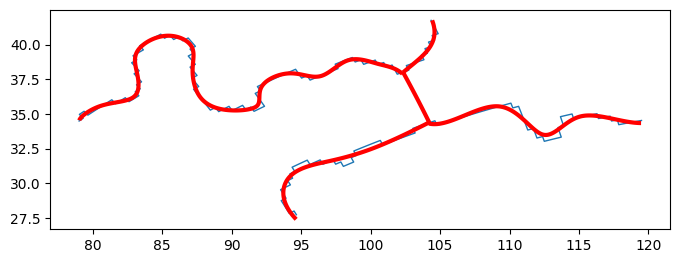

In [182]:
#插值的方式得到平滑的曲线
def smooth_line_bspline(line, smooth_factor=0.001, n_points=500):

    coords = np.array(line.coords)

    # 去除重复点（非常重要）
    _, idx = np.unique(coords, axis=0, return_index=True)
    coords = coords[np.sort(idx)]

    if len(coords) < 4:
        return line  # 点太少，直接返回

    x, y = coords[:, 0], coords[:, 1]

    # B-spline
    tck, u = splprep([x, y], s=smooth_factor)
    u_new = np.linspace(0, 1, n_points)
    x_new, y_new = splev(u_new, tck)

    return LineString(np.column_stack([x_new, y_new]))

def smooth_segments_bspline(segments_gdf, smooth_factor=0.001):
    geoms = []
    for geom in segments_gdf.geometry:
        geoms.append(smooth_line_bspline(geom, smooth_factor=smooth_factor))
    out = segments_gdf.copy()
    out.geometry = geoms
    return out

smooth_segments = smooth_segments_bspline(segments, smooth_factor=4)

fig, ax = plt.subplots(figsize=(8, 8))
segments.plot(ax=ax, linewidth=1)
smooth_segments.plot(ax=ax, linewidth=3, color='red')
ax.set_aspect("equal")
plt.show()

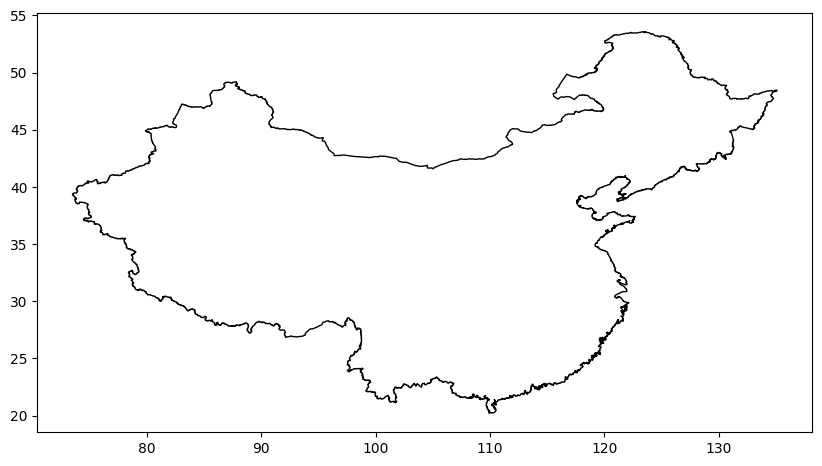

In [183]:
#提取中国大陆部分
# ---- 1. 读取并清理数据 ----
china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
china = china[china['name'] != '境界线'].reset_index(drop=True)

# ---- 2. 合并所有行政区 polygon ----
china_dissolved = china.dissolve()

geom = china_dissolved.geometry.iloc[0]  # dissolved 后只有一行
polygons = []
if geom.geom_type == 'Polygon':
    polygons = [geom]
elif geom.geom_type == 'MultiPolygon':
    polygons = list(geom.geoms)

# ---- 4. 按面积排序，选择最大的 polygon ----
largest_poly = max(polygons, key=lambda p: p.area)

# ---- 5. 构建 GeoDataFrame ----
china_mainland = gpd.GeoDataFrame({'geometry': [largest_poly]}, crs=china.crs)

# ---- 绘图检查 ----

fig, ax = plt.subplots(figsize=(10, 10))
china_mainland.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_aspect('equal')
plt.show()

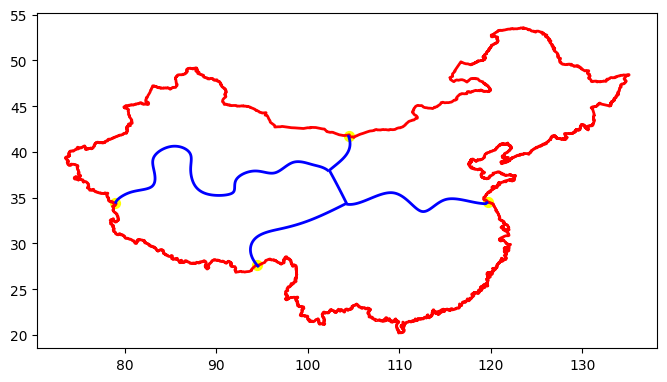

In [184]:
#找到内部边界线和中国国境线的交点
# 主大陆外环
mainland_poly = china_mainland.geometry.iloc[0]
main_boundary = LineString(mainland_poly.exterior.coords)

# -------------------------------
# 1️⃣ 计算每条曲线到主大陆的最短距离
# -------------------------------
distances = []
for idx, row in smooth_segments.iterrows():
    line = row.geometry
    # nearest_points 返回线到边界的最近点对
    nearest = nearest_points(line, main_boundary)
    dist = nearest[0].distance(nearest[1])
    distances.append(dist)

# 找到距离最远的那条曲线索引（不延长）
max_idx = distances.index(max(distances))

# -------------------------------
# 2️⃣ 延长曲线函数（只延长没有交点的曲线）
# -------------------------------
def extend_line_to_boundary(line, boundary, extend_ratio=1.0):
    coords = list(line.coords)
    start, end = Point(coords[0]), Point(coords[-1])
    
    nearest_start = nearest_points(start, boundary)[1]
    nearest_end   = nearest_points(end, boundary)[1]
    
    dist_start = start.distance(nearest_start)
    dist_end   = end.distance(nearest_end)
    
    # 延长距离近的一端
    if dist_start < dist_end:
        vec = (nearest_start.x - start.x, nearest_start.y - start.y)
        new_start = (start.x + vec[0]*extend_ratio, start.y + vec[1]*extend_ratio)
        new_coords = [new_start] + coords[1:]
    else:
        vec = (nearest_end.x - end.x, nearest_end.y - end.y)
        new_end = (end.x + vec[0]*extend_ratio, end.y + vec[1]*extend_ratio)
        new_coords = coords[:-1] + [new_end]
    
    return LineString(new_coords)

# -------------------------------
# 3️⃣ 延长内部曲线（排除距离最远的那条）
# -------------------------------
extended_lines = []
for idx, row in smooth_segments.iterrows():
    line = row.geometry
    inter = line.intersection(main_boundary)
    
    if idx == max_idx:
        # 不延长
        extended_lines.append(line)
        continue

    if inter.is_empty:
        # 没有交点 → 延长
        extended_line = extend_line_to_boundary(line, main_boundary, extend_ratio=1.2)
        extended_lines.append(extended_line)
    else:
        # 已有交点 → 保留原线
        extended_lines.append(line)

# -------------------------------
# 4️⃣ 求交点
def get_intersections(lines, boundary):
    points = []
    for line in lines:
        inter = line.intersection(boundary)
        if inter.is_empty:
            continue
        if isinstance(inter, Point):
            points.append(inter)
        elif isinstance(inter, MultiPoint):
            points.extend(inter.geoms)
        elif inter.geom_type in ["LineString", "MultiLineString"]:
            if inter.geom_type == "LineString":
                points.extend([Point(inter.coords[0]), Point(inter.coords[-1])])
            else:
                for l in inter.geoms:
                    points.extend([Point(l.coords[0]), Point(l.coords[-1])])
        elif inter.geom_type == "GeometryCollection":
            for g in inter.geoms:
                if g.is_empty:
                    continue
                if g.geom_type == "Point":
                    points.append(g)
                elif g.geom_type == "MultiPoint":
                    points.extend(g.geoms)
    return points

intersection_points = get_intersections(extended_lines, main_boundary)

# -------------------------------
# 5️⃣ 可视化检查
fig, ax = plt.subplots(figsize=(8,8))
gpd.GeoSeries(main_boundary).plot(ax=ax, color="red", linewidth=2, label="Main China Boundary")
gpd.GeoSeries(extended_lines).plot(ax=ax, color="blue", linewidth=2, label="Extended Lines")
gpd.GeoSeries(intersection_points).plot(ax=ax, color="yellow", markersize=50, label="Intersection Points")
ax.set_aspect("equal")
# plt.legend()
plt.show()

Extended Lines:
   line_id                                           geometry
0        1  LINESTRING (78.94202 34.35723, 79.03938 34.569...
1        2  LINESTRING (94.64038 27.41806, 94.61083 27.449...
2        3  LINESTRING (102.34989 38.00172, 102.35721 38.0...
3        4  LINESTRING (104.22749 34.37389, 104.22386 34.3...
4        5  LINESTRING (104.19831 34.30954, 104.23108 34.3...

Intersection Points:
   point_id                    geometry
0         1   POINT (78.95624 34.38819)
1         2   POINT (94.47102 27.60366)
2         3  POINT (104.52262 41.73576)
3         4  POINT (119.64824 34.52595)


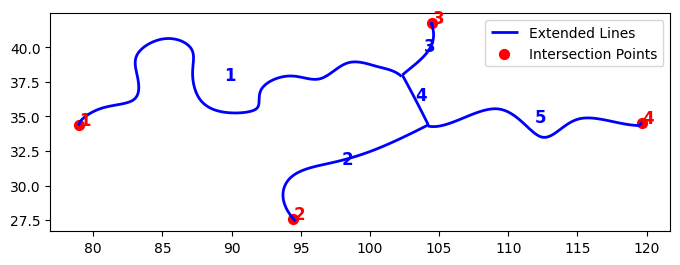

In [185]:
#标记内部边界线和交点
# -------------------------------
# 1️⃣ extended_lines → GeoDataFrame
# -------------------------------
extended_lines_gdf = gpd.GeoDataFrame(
    {
        "line_id": range(1, len(extended_lines)+1)  # 给每条曲线编号 1~5
    },
    geometry=extended_lines,
    crs="EPSG:4326"  # 替换为你的 CRS
)

# 检查
print("Extended Lines:")
print(extended_lines_gdf)

# -------------------------------
# 2️⃣ intersection_points → GeoDataFrame
# -------------------------------
# 如果 intersection_points 是 GeoDataFrame 已经有 geometry，可以直接添加列
if hasattr(intersection_points, "geometry"):
    intersection_points_gdf = intersection_points.copy()
    intersection_points_gdf = intersection_points_gdf.reset_index(drop=True)
    intersection_points_gdf["point_id"] = range(1, len(intersection_points_gdf)+1)
else:
    # 如果 intersection_points 是列表
    intersection_points_gdf = gpd.GeoDataFrame(
        {
            "point_id": range(1, len(intersection_points)+1)
        },
        geometry=intersection_points,
        crs="EPSG:4326"
    )

# 检查
print("\nIntersection Points:")
print(intersection_points_gdf)

# -------------------------------
# 3️⃣ 可视化检查（可选）
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))
extended_lines_gdf.plot(ax=ax, color="blue", linewidth=2, label="Extended Lines")
intersection_points_gdf.plot(ax=ax, color="red", markersize=50, label="Intersection Points")

# 显示编号
for idx, row in extended_lines_gdf.iterrows():
    x, y = row.geometry.centroid.coords[0]
    ax.text(x, y, str(row.line_id), color="blue", fontsize=12, fontweight="bold")

for idx, row in intersection_points_gdf.iterrows():
    x, y = row.geometry.coords[0]
    ax.text(x, y, str(row.point_id), color="red", fontsize=12, fontweight="bold")

ax.set_aspect("equal")
plt.legend()
plt.show()

   boundary_id                                           geometry
0            1  LINESTRING (94.47102 27.60366, 94.46778 27.602...
1            2  LINESTRING (78.95624 34.38819, 78.95093 34.387...
2            3  LINESTRING (104.52262 41.73576, 104.52119 41.6...
3            4  LINESTRING (119.64824 34.52595, 119.64069 34.5...


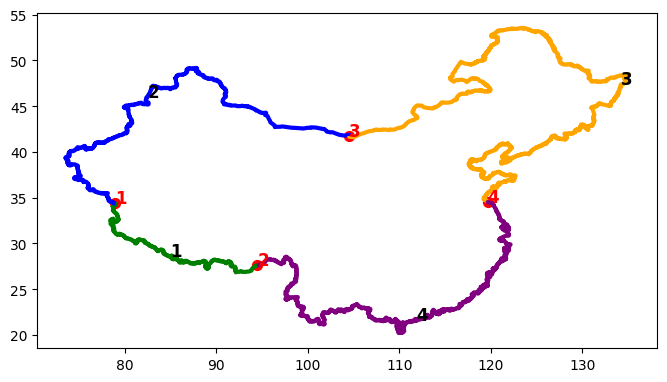

In [186]:
#标记中国国境线
# 1️⃣ 获取边界坐标
coords = list(main_boundary.coords)

# 2️⃣ 将交点插入到最近线段
def insert_point(coords, pt):
    min_dist = float('inf')
    insert_idx = 0
    pt_coords = pt.coords[0]
    for i in range(len(coords)-1):
        seg = LineString([coords[i], coords[i+1]])
        d = seg.distance(pt)
        if d < min_dist:
            min_dist = d
            insert_idx = i+1
    coords.insert(insert_idx, pt_coords)
    return coords

coords_with_points = coords.copy()
for pt in intersection_points:
    coords_with_points = insert_point(coords_with_points, pt)

# 3️⃣ 找到交点在坐标中的索引
point_indices = []
for pt in intersection_points:
    for i, c in enumerate(coords_with_points):
        if abs(c[0]-pt.x)<1e-8 and abs(c[1]-pt.y)<1e-8:
            point_indices.append(i)
            break

# 4️⃣ 确保索引按顺时针顺序排列
point_indices = sorted(point_indices)

# 5️⃣ 切分闭合环，保证段数 = 交点数
n_points = len(point_indices)
boundary_segments = []

for i in range(n_points):
    start_idx = point_indices[i]
    end_idx = point_indices[(i+1) % n_points]  # 环形切分
    if end_idx > start_idx:
        seg_coords = coords_with_points[start_idx:end_idx+1]
    else:
        # 跨越起点
        seg_coords = coords_with_points[start_idx:] + coords_with_points[:end_idx+1]
    boundary_segments.append(LineString(seg_coords))

# -------------------------------
# 6️⃣ 构建 GeoDataFrame 并编号
boundary_segments_gdf = gpd.GeoDataFrame(
    {"boundary_id": range(1, len(boundary_segments)+1)},
    geometry=boundary_segments,
    crs="EPSG:4326"
)

print(boundary_segments_gdf)

# -------------------------------
# 7️⃣ 可视化
colors = ["green", "blue", "orange", "purple"]  # 每段不同颜色
fig, ax = plt.subplots(figsize=(8,8))

for idx, seg in enumerate(boundary_segments):
    gpd.GeoSeries([seg]).plot(ax=ax, color=colors[idx % len(colors)], linewidth=3, label=f"Segment {idx+1}")

# 绘制交点
gpd.GeoSeries(intersection_points).plot(ax=ax, color="red", markersize=50, label="Intersection Points")

# 显示编号
for idx, row in enumerate(boundary_segments):
    x, y = row.interpolate(0.5, normalized=True).coords[0]
    ax.text(x, y, str(idx+1), color="black", fontsize=12, fontweight="bold")

for idx, pt in enumerate(intersection_points):
    ax.text(pt.x, pt.y, str(idx+1), color="red", fontsize=12, fontweight="bold")

ax.set_aspect("equal")
# plt.legend()
plt.show()

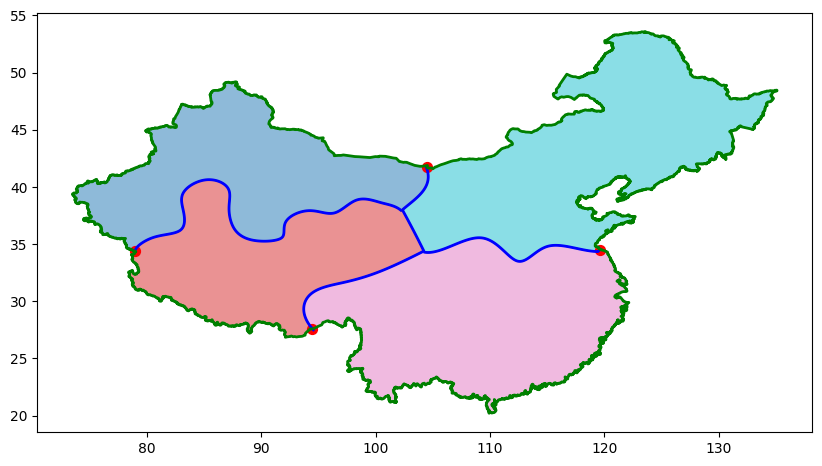

In [187]:
#合并边界
# -------------------------------
# 辅助函数：将 LineString 或 Point 转为坐标列表
def geometry_to_coords(geom):
    if isinstance(geom, LineString):
        return list(geom.coords)
    elif isinstance(geom, Point):
        return [(geom.x, geom.y)]
    else:
        raise TypeError(f"Unsupported geometry type: {type(geom)}")

# -------------------------------
# 端点距离最小原则连接两条曲线
def connect_two_lines_min_distance(line1_coords, line2_coords):
    combinations = [
        (np.linalg.norm(np.array(line1_coords[0])-np.array(line2_coords[0])), "start1_start2"),
        (np.linalg.norm(np.array(line1_coords[0])-np.array(line2_coords[-1])), "start1_end2"),
        (np.linalg.norm(np.array(line1_coords[-1])-np.array(line2_coords[0])), "end1_start2"),
        (np.linalg.norm(np.array(line1_coords[-1])-np.array(line2_coords[-1])), "end1_end2"),
    ]
    case = min(combinations, key=lambda x:x[0])[1]

    if case == "start1_start2":
        new_coords = line2_coords[::-1] + line1_coords[1:]
    elif case == "start1_end2":
        new_coords = line2_coords + line1_coords[1:]
    elif case == "end1_start2":
        new_coords = line1_coords + line2_coords[1:]
    elif case == "end1_end2":
        new_coords = line1_coords + line2_coords[::-1][1:]
    return new_coords

# -------------------------------
# 区域4特殊处理：line5 → line4 → line3 → boundary3
def build_region4(extended_lines_gdf, boundary_segments_gdf):
    # 获取几何
    line5 = extended_lines_gdf.loc[extended_lines_gdf['line_id']==5,'geometry'].values[0]
    line4 = extended_lines_gdf.loc[extended_lines_gdf['line_id']==4,'geometry'].values[0]
    line3 = extended_lines_gdf.loc[extended_lines_gdf['line_id']==3,'geometry'].values[0]
    boundary3 = boundary_segments_gdf.loc[boundary_segments_gdf['boundary_id']==3,'geometry'].values[0]

    coords5 = list(line5.coords)
    coords4 = list(line4.coords)
    coords3 = list(line3.coords)
    coords_b3 = list(boundary3.coords)

    # line5 → line4
    coords_line = connect_two_lines_min_distance(coords5, coords4)
    # line4 → line3
    coords_line = connect_two_lines_min_distance(coords_line, coords3)
    # line3 → boundary3
    start_dist = np.linalg.norm(np.array(coords_line[-1])-np.array(coords_b3[0]))
    end_dist = np.linalg.norm(np.array(coords_line[-1])-np.array(coords_b3[-1]))
    if start_dist <= end_dist:
        coords_line.extend(coords_b3[1:])
    else:
        coords_line.extend(coords_b3[::-1][1:])

    coords_line.append(coords_line[0])
    return Polygon(coords_line)

# -------------------------------
# 通用区域构建（除区域4）
def build_region_general(conn, extended_lines_gdf, boundary_segments_gdf, intersection_points_gdf):
    coords = []
    prev_end = None
    for item in conn:
        if item.startswith("line"):
            line_id = int(item[4:])
            geom = extended_lines_gdf.loc[extended_lines_gdf['line_id']==line_id,'geometry'].values[0]
            pts = geometry_to_coords(geom)
            if prev_end is None:
                coords.extend(pts)
                prev_end = coords[-1]
            else:
                start_dist = np.linalg.norm(np.array(prev_end)-np.array(pts[0]))
                end_dist = np.linalg.norm(np.array(prev_end)-np.array(pts[-1]))
                if start_dist <= end_dist:
                    pts_aligned = pts
                else:
                    pts_aligned = pts[::-1]
                coords.extend(pts_aligned[1:])
                prev_end = pts_aligned[-1]

        elif item.startswith("boundary"):
            boundary_id = int(item[8:])
            geom = boundary_segments_gdf.loc[boundary_segments_gdf['boundary_id']==boundary_id,'geometry'].values[0]
            pts = geometry_to_coords(geom)
            if prev_end is None:
                coords.extend(pts)
                prev_end = coords[-1]
            else:
                start_dist = np.linalg.norm(np.array(prev_end)-np.array(pts[0]))
                end_dist = np.linalg.norm(np.array(prev_end)-np.array(pts[-1]))
                if start_dist <= end_dist:
                    pts_aligned = pts
                else:
                    pts_aligned = pts[::-1]
                coords.extend(pts_aligned[1:])
                prev_end = pts_aligned[-1]

        elif item.startswith("point"):
            point_id = int(item[5:])
            geom = intersection_points_gdf.loc[intersection_points_gdf['point_id']==point_id,'geometry'].values[0]
            pt = (geom.x, geom.y)
            if prev_end is not None and np.linalg.norm(np.array(prev_end)-np.array(pt))>1e-12:
                coords.append(pt)
            prev_end = pt
        else:
            raise ValueError(f"Unknown item: {item}")

    coords.append(coords[0])
    return Polygon(coords)

# -------------------------------
# 构建全部区域
def build_all_regions(extended_lines_gdf, boundary_segments_gdf, intersection_points_gdf, regions_connections):
    polygons = []
    region_ids = []

    for rid, conn in enumerate(regions_connections, start=1):
        if rid == 4:
            poly = build_region4(extended_lines_gdf, boundary_segments_gdf)
        else:
            poly = build_region_general(conn, extended_lines_gdf, boundary_segments_gdf, intersection_points_gdf)
        polygons.append(poly)
        region_ids.append(rid)

    regions_gdf = gpd.GeoDataFrame(
        {"region_id": region_ids},
        geometry=polygons,
        crs=extended_lines_gdf.crs
    )
    return regions_gdf

# -------------------------------
# 可视化
def plot_regions(regions_gdf, extended_lines_gdf=None, boundary_segments_gdf=None, intersection_points_gdf=None):
    fig, ax = plt.subplots(figsize=(10,10))
    regions_gdf.plot(ax=ax, edgecolor="black", alpha=0.5, column="region_id", cmap="tab10")
    if extended_lines_gdf is not None:
        extended_lines_gdf.plot(ax=ax, color="blue", linewidth=2)
    if boundary_segments_gdf is not None:
        boundary_segments_gdf.plot(ax=ax, color="green", linewidth=2)
    if intersection_points_gdf is not None:
        intersection_points_gdf.plot(ax=ax, color="red", markersize=50)
    ax.set_aspect("equal")
    plt.show()

# -------------------------------
# 示例连接顺序
regions_connections = [
    ["line1","line3","boundary2"],               # 区域1
    ["line1","line4","line2","boundary1"],       # 区域2
    ["line2","line5","boundary4"],               # 区域3
    ["line5","line4","line3","boundary3"]        # 区域4, 单独处理
]

# -------------------------------
regions_gdf = build_all_regions(
    extended_lines_gdf,
    boundary_segments_gdf,
    intersection_points_gdf,
    regions_connections
)

plot_regions(regions_gdf, extended_lines_gdf, boundary_segments_gdf, intersection_points_gdf)

EPSG:4490


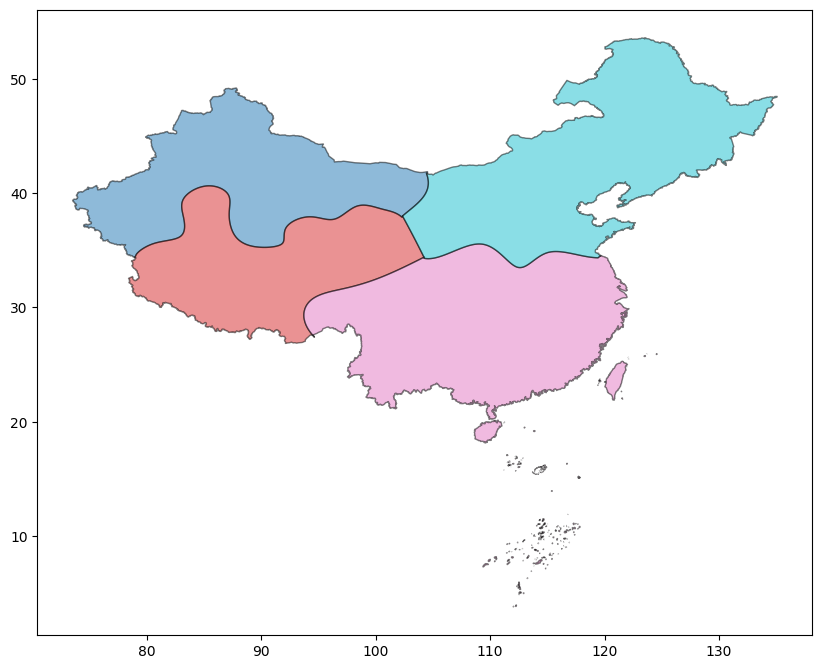

In [188]:
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union

# -------------------------------
# 读取中国边界
china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
china = china[china['name'] != '境界线'].reset_index(drop=True)
print(china.crs)
# 选择台湾省和海南省
island = china[(china['name'] == '台湾省') | (china['name'] == '海南省')]

# -------------------------------
# 将岛屿添加到 region_id=3
region3_geom = regions_gdf.loc[regions_gdf['region_id'] == 3, 'geometry'].values[0]

# 修复 region3 的几何
if not region3_geom.is_valid:
    region3_geom = region3_geom.buffer(0)

# 展开 island 的 MultiPolygon，收集所有 Polygon
island_polygons = []
for g in island.geometry:
    if not g.is_valid:
        g = g.buffer(0)
    if isinstance(g, Polygon):
        island_polygons.append(g)
    elif isinstance(g, MultiPolygon):
        island_polygons.extend(list(g.geoms))  # 展开 MultiPolygon

# 展开 region3_geom，如果它本身是 MultiPolygon
if isinstance(region3_geom, MultiPolygon):
    region3_polygons = list(region3_geom.geoms)
else:
    region3_polygons = [region3_geom]

# 合并 region3 + 所有岛屿 Polygon
all_polygons = region3_polygons + island_polygons
# 过滤掉 None
all_polygons = [p for p in all_polygons if p is not None]

# 构建新的 MultiPolygon
new_region3_geom = MultiPolygon(all_polygons)

# 更新 regions_gdf
regions_gdf.loc[regions_gdf['region_id'] == 3, 'geometry'] = new_region3_geom

# -------------------------------
import matplotlib.pyplot as plt

# -------------------------------
# 可视化，确保同一个 region 使用同一种颜色
fig, ax = plt.subplots(figsize=(10, 10))

# regions_gdf 以 region_id 显示颜色
regions_gdf.plot(
    ax=ax,
    column="region_id",       # 按区域编号分颜色
    cmap="tab10",             # 可选 colormap
    edgecolor="black",
    alpha=0.5,
    legend=False               # 显示图例
)

# 如果你想标出岛屿边界，可以单独画
# island.boundary.plot(ax=ax, color="red", linewidth=1)

ax.set_aspect("equal")
plt.show()

In [189]:
# ---- 转换坐标系为 EPSG:4490 ----
regions_gdf_4490 = regions_gdf.to_crs(epsg=4490)

# ---- 导出为 GeoJSON ----
regions_gdf_4490.to_file("output/regions_boundary_20260115.geojson", driver="GeoJSON")

print("已成功导出 regions.geojson，CRS 为 EPSG:4490")

已成功导出 regions.geojson，CRS 为 EPSG:4490
